In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

In [3]:
import sys, pathlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [89]:
def process_and_compute_efficiency(dyno_files, motec_files, target_torque=150,
                                   rpm_diff_tol=None, rolling_window=3, plot=True):
    """
    Process dyno and MoTeC data and compute motor efficiency.
    
    Parameters:
    - dyno_df: DataFrame with dyno data indexed by run ID
    - motec_files: list of MoTeC file paths
    - dyno_ids: list of corresponding dyno IDs for each MoTeC file
    - target_torque: torque to filter by (Nm)
    - rpm_diff_tol: if given, only match points within ±rpm_diff_tol
    - rolling_window: window for rolling mean smoothing
    - plot: if True, generate scatter plot of efficiency vs RPM
    
    Returns:
    - combined_df: concatenated DataFrame with efficiency calculations
    """
    
    all_runs = []
    
    for motec_file, dyno_file in zip(motec_files, dyno_files):
        # --- Load dyno ---
        #print(f'Dyno_Data/{dyno_file}')
        cur_dyno_df = pd.read_csv(f'Dyno_Data/{dyno_file}', index_col=0, parse_dates=True)
        cur_dyno_df = cur_dyno_df.dropna(subset=['Axle Speed (rpm)', 'Axle Torque (Nm)'])
        
        rpm_min = cur_dyno_df["Axle Speed (rpm)"].min()
        rpm_max = cur_dyno_df["Axle Speed (rpm)"].max()
        
        # --- Load MoTeC ---
        motec_df = pd.read_csv(f'Motec_Data/CSV Export/{motec_file}', skiprows=[10], header=8)


        #print(rpm_min, rpm_max)
        
        # Filter by RPM range and target torque
        motec_trim = motec_df[
            (motec_df["Car.Data.Motor.MotorRPM"] >= rpm_min) &
            (motec_df["Car.Data.Motor.MotorRPM"] <= rpm_max) &
            (motec_df['Car.Data.Inverter.InverterCalculatedTorque'] >= target_torque)
        ].copy()
        
        # Only keep monotonic increasing RPM
        motec_trim = motec_trim[motec_trim["Car.Data.Motor.MotorRPM"].diff() > 0]
        
        # Rolling mean smoothing
        motec_trim = motec_trim.rolling(rolling_window).mean().dropna()
        
        # --- Nearest neighbor matching ---
        dyno_features = cur_dyno_df[['Axle Speed (rpm)', 'Axle Torque (Nm)']].to_numpy()
        #print(dyno_features)
        motec_features = motec_trim[['Car.Data.Motor.MotorRPM', 'Car.Data.Inverter.InverterCalculatedTorque']].to_numpy()
        #print(motec_features)
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(dyno_features)
        distances, indices = nn.kneighbors(motec_features)
        
        matched_dyno = cur_dyno_df.iloc[indices.flatten()].reset_index(drop=True)
        matched_motec = motec_trim.reset_index(drop=True)
        
        # Optional RPM difference filter
        if rpm_diff_tol is not None:
            rpm_diff = np.abs(matched_dyno['Axle Speed (rpm)'] - matched_motec['Car.Data.Motor.MotorRPM'])
            keep = rpm_diff <= rpm_diff_tol
            matched_dyno = matched_dyno[keep].reset_index(drop=True)
            matched_motec = matched_motec[keep].reset_index(drop=True)
        
        # --- Compute efficiency ---
        matched_df = matched_motec.copy()
        matched_df['P_out'] = matched_dyno['Axle Torque (Nm)'] * 2*np.pi*matched_dyno['Axle Speed (rpm)']/60 / 1000
        matched_df['P_in'] = matched_motec['Car.Data.Battery.BatteryPower'] / 100000
        matched_df['eff'] = matched_df['P_out'] / matched_df['P_in']
        
        all_runs.append(matched_df)
    
    # --- Combine all runs ---
    combined_df = pd.concat(all_runs, ignore_index=True)
    combined_df = combined_df[combined_df['eff'] < 1]  # sanity filter
    
    # --- Plot ---
    if plot:
        plt.figure(figsize=(10,5))
        plt.scatter(combined_df['Car.Data.Motor.MotorRPM'], combined_df['eff'], s=5, alpha=0.7)
        plt.xlabel("RPM")
        plt.ylabel("Efficiency")
        plt.title(f"Motor Efficiency vs RPM (Torque = {target_torque} Nm)")
        plt.grid(True)
        plt.show()
    
    return combined_df

In [30]:
from pathlib import Path


folder = Path("Dyno_Data")

csv_files = [f.name for f in folder.glob('*.csv')]

print(csv_files)

['speedramp3_pl70_manual_dhruv.csv', 'speedramp6_pl100_manual_dhruv.csv', 'speedramp9_pl130_manual_dhruv.csv', 'speedramp7_pl110_manual_dhruv.csv', 'speedramp12_pl160_maual_dhruv_failed.csv', 'speedramp4_pl80_manual_dhruv.csv', 'speedramp1_pl50_manual_dhruv.csv', 'speedramp13_pl167-1_manual_dhruv_failed.csv', 'speedramp8_pl120_manual_dhruv.csv', 'speedramp11_pl150_manual_dhruv.csv', 'speedramp2_pl60_manual_dhruv.csv', 'speedramp10_pl140_manual_dhruv.csv', 'speedramp5_pl90_manual_dhruv.csv']


In [31]:
import re
def extract_run_number(filename):
    return int(re.search(r"speedramp(\d+)", filename).group(1))

# filter out 13, then sort
sorted_dyno_files = sorted(
    [f for f in csv_files if extract_run_number(f) <= 12],
    key=extract_run_number
)

print(sorted_dyno_files[0])

speedramp1_pl50_manual_dhruv.csv


In [91]:
df_test = pd.read_csv(f'Dyno_Data/{sorted_dyno_files[0]}', index_col=0, parse_dates=True)
df_test

,Axle Torque (Nm),Axle Speed (rpm),Power (kW),TqC (Nm),Time (sec),Tailshaft Speed (rpm),Speed (km/h),Tacho [Rat] (rpm),Speed L (rpm),Tq L (Nm),Speed R (rpm),Axle Tq R (Nm),Comments
Run Name,,,,,,,,,,,,,
MUREV2025.0028,142.5,756.52,11.249,43.506,1.30,2958.0,58.025,2469.1,759.0,97.5,754.1,45.0,NaN
MUREV2025.0028,142.5,755.80,11.252,43.562,1.35,2955.2,57.967,2466.7,758.2,98.0,753.4,44.5,NaN
MUREV2025.0028,142.5,756.00,11.229,43.500,1.40,2956.0,57.931,2465.2,758.4,98.5,753.6,44.0,NaN
MUREV2025.0028,142.5,756.52,11.226,43.498,1.45,2958.0,57.917,2464.6,759.0,98.5,754.0,44.0,NaN
MUREV2025.0028,142.0,757.60,11.200,43.380,1.50,2962.2,57.938,2465.5,760.2,98.5,755.0,43.5,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
MUREV2025.0028,149.0,1418.40,22.021,45.523,14.90,5545.9,108.554,4619.4,1418.8,39.5,1418.0,109.5,NaN
MUREV2025.0028,149.0,1414.56,21.996,45.512,14.95,5530.9,108.454,4615.1,1415.8,39.5,1413.3,109.5,NaN
MUREV2025.0028,148.5,1403.56,21.851,45.357,15.00,5487.9,108.108,4600.4,1407.2,39.0,1399.9,109.5,NaN


In [33]:
folder = Path("Motec_Data/CSV Export")

csv_motec_files = [f.name for f in folder.glob('*.csv')]

print(csv_motec_files)

['dryno_morning_torquemapping_withshudderissue_4.csv', 'dryno_morning_torquemapping_withshudderissue_5.csv', 'dryno_morning_torquemapping_withshudderissue_7.csv', 'dryno_morning_torquemapping_withshudderissue_6.csv', 'dryno_morning_torquemapping_withshudderissue_2.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_11.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_10.csv', 'dryno_morning_torquemapping_withshudderissue_3.csv', 'dryno_morning_torquemapping_withshudderissue_1.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_12.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_2.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_1.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_6.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv']


In [34]:
def extract_num(f):
    return int(re.search(r"_(\d+)\.csv", f).group(1))

# filter + sort
motec_sorted = sorted(
    [f for f in csv_motec_files if "dyno_arvo" in f],
    key=extract_num
)

print(motec_sorted)

['dyno_arvo_shudderfix_andlowrpmspeedramp_1.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_2.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_3.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_4.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_5.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_6.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_7.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_8.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_9.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_10.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_11.csv', 'dyno_arvo_shudderfix_andlowrpmspeedramp_12.csv']


In [84]:
print(motec_sorted[0])
df_test = pd.read_csv(f'Motec_Data/CSV Export/{motec_sorted[0]}', index_col=0, skiprows=[10], header=8 )

# drop the units row
df_test = df_test.iloc[1:].reset_index(drop=True)

df_test

dyno_arvo_shudderfix_andlowrpmspeedramp_1.csv


,Car.DigitalInput.MSS.PDOC.Pin,Car.DigitalInput.MSS.BMS.Pin,Car.DigitalInput.MSS.BSPD.Pin,Car.DigitalInput.MSS.IMD.Pin,Car.Data.Driver.ThrottlePressure,Car.Data.Motor.MotorRPM,Car.AnalogInput.BMS.CellTempASensor,Car.AnalogInput.BMS.CellTempBSensor,Car.AnalogInput.BMS.CellTempCSensor,Car.Data.Battery.PackSOC,...,Car.Data.IMU.Rear.AccelX,Car.Data.IMU.Rear.GyroZ,Car.Data.IMU.Rear.GyroY,Car.Data.IMU.Rear.GyroX,Car.Data.IMU.Rear.VelD,Car.Data.IMU.Rear.VelE,Car.Data.IMU.Rear.VelN,Car.DigitalInput.WheelSpeed.WheelSpeedFrontLeft,Car.DigitalInput.WheelSpeed.WheelSpeedFrontRight,Car.Data.Inverter.InverterCalculatedTorque
0,0,0,0,0,0,0,0.169765,0.000023,0.169282,49,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0.339530,0.000047,0.338564,49,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0.509295,0.000070,0.507846,49,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0.679060,0.000093,0.677128,49,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0.848825,0.000117,0.846410,49,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
695,1,1,1,1,0,0,1.698030,0.000330,1.693330,49,...,0,0,0,0,0,0,0,0,0,0
696,1,1,1,1,0,0,1.698110,0.000313,1.693370,49,...,0,0,0,0,0,0,0,0,0,0
697,1,1,1,1,0,0,1.698190,0.000295,1.693400,49,...,0,0,0,0,0,0,0,0,0,0
698,1,1,1,1,0,0,1.698270,0.000278,1.693440,49,...,0,0,0,0,0,0,0,0,0,0


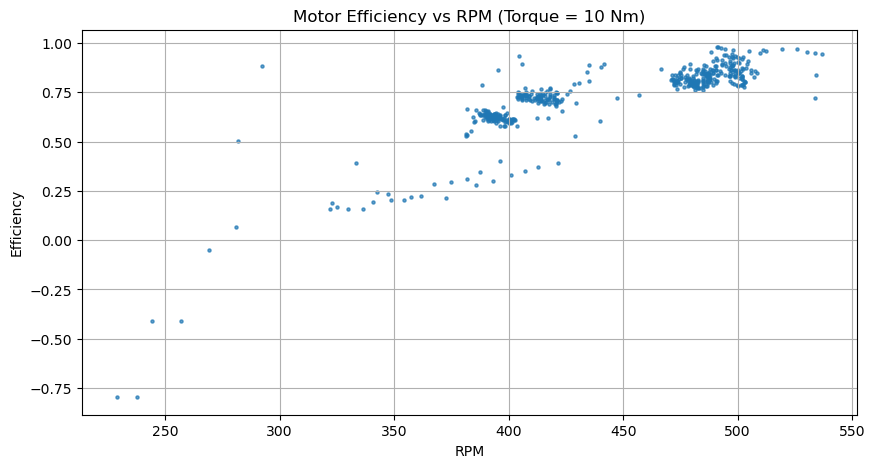

,Time,Car.DigitalInput.MSS.PDOC.Pin,Car.DigitalInput.MSS.BMS.Pin,Car.DigitalInput.MSS.BSPD.Pin,Car.DigitalInput.MSS.IMD.Pin,Car.Data.Driver.ThrottlePressure,Car.Data.Motor.MotorRPM,Car.AnalogInput.BMS.CellTempASensor,Car.AnalogInput.BMS.CellTempBSensor,Car.AnalogInput.BMS.CellTempCSensor,...,Car.Data.IMU.Rear.GyroX,Car.Data.IMU.Rear.VelD,Car.Data.IMU.Rear.VelE,Car.Data.IMU.Rear.VelN,Car.DigitalInput.WheelSpeed.WheelSpeedFrontLeft,Car.DigitalInput.WheelSpeed.WheelSpeedFrontRight,Car.Data.Inverter.InverterCalculatedTorque,P_out,P_in,eff
7126,3580.486667,0.0,0.0,0.0,0.0,37.666667,250.666667,1.541483,0.004764,1.541080,...,0.0,0.0,0.0,0.0,0.0,0.0,62.666667,-0.105558,0.000000,-inf
7127,3580.503333,0.0,0.0,0.0,0.0,40.666667,262.333333,1.541013,0.005050,1.540463,...,0.0,0.0,0.0,0.0,0.0,0.0,67.666667,-0.014458,0.000000,-inf
7144,3581.000000,0.0,0.0,0.0,0.0,99.000000,534.000000,1.534940,0.015258,1.527833,...,0.0,0.0,0.0,0.0,0.0,0.0,150.000000,9.481211,11.346607,0.835599
7145,3581.056667,0.0,0.0,0.0,0.0,99.000000,342.333333,1.536313,0.014939,1.529950,...,0.0,0.0,0.0,0.0,0.0,0.0,150.000000,3.653756,15.025033,0.243178
7146,3581.073333,0.0,0.0,0.0,0.0,99.000000,347.333333,1.536353,0.014840,1.530900,...,0.0,0.0,0.0,0.0,0.0,0.0,150.000000,3.653756,15.654133,0.233405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7878,3633.353333,0.0,0.0,0.0,0.0,99.333333,526.000000,1.523400,0.015435,1.520530,...,0.0,0.0,0.0,0.0,0.0,0.0,166.000000,9.481211,9.775433,0.969902
7879,3633.376667,0.0,0.0,0.0,0.0,99.000000,530.333333,1.523380,0.015377,1.521440,...,0.0,0.0,0.0,0.0,0.0,0.0,166.000000,9.481211,9.915417,0.956209
7880,3633.400000,0.0,0.0,0.0,0.0,99.000000,533.666667,1.523327,0.015343,1.521727,...,0.0,0.0,0.0,0.0,0.0,0.0,166.000000,9.481211,10.009683,0.947204
7881,3633.423333,0.0,0.0,0.0,0.0,99.000000,536.666667,1.523217,0.015347,1.521077,...,0.0,0.0,0.0,0.0,0.0,0.0,166.000000,9.481211,10.021600,0.946078


In [90]:
process_and_compute_efficiency(sorted_dyno_files[1:], motec_sorted[1:], target_torque=10, rpm_diff_tol=None, rolling_window=3, plot=True)

speedramp2_pl60_manual_dhruv.csv


<Axes: >

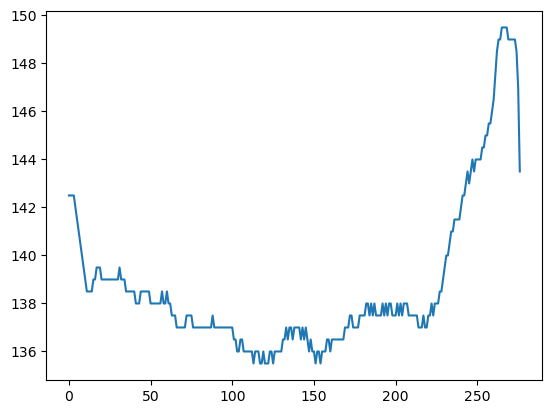

In [85]:
print(sorted_dyno_files[1])
pd.read_csv(f'Dyno_Data/{sorted_dyno_files[0]}', parse_dates=True)['Axle Torque (Nm)'].plot()